In [50]:
import os
from tqdm import tqdm
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from pathlib import Path
import xarray as xr


In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
root_dir = Path(os.getcwd()).parent.parent.parent

# Add the root directory to Python path
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from models.architectures.Unet import Unet
from src.seed import set_seed, seed_worker, set_device
from src.data_pipeline.loaders.data_loaders import get_data_loaders
from src.data_pipeline.sourcing.downloaders.download_data import download_data
from src.data_pipeline.preprocessing.preprocess import normalize99

C:\Users\atle_\AppData\Roaming\Python\Python312\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [46]:
SEED = 2025
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2025 has been set.


### Load Dataset

In [47]:
data_dir = root_dir / 'data' / 'ca_imaging'

Create data class

In [48]:
class CellsDataset(Dataset):
    def __init__(self) -> None:
        super(CellsDataset, self).__init__()

        # load dataset
        dataset = xr.load_dataset(data_dir / 'cells_data_all.nc')

        # extract images and labels from dataset
        self.images = torch.from_numpy(dataset['ca_image_data'].values).float()
        self.labels = torch.from_numpy(dataset['cell_labels'].values).float()

    def __len__(self):
        """Get the number of images in dataset"""
        return len(self.images)
    
    def __getitem__(self, index):
        """Get a specific image and its cell labels"""
        return self.images[index], self.labels[index]

Load cell data class

In [58]:
cells_data = CellsDataset()

Split data into train, validation, and test sets

In [ ]:


train_proportion = 0.7
val_proportion = 0.15

train_size = int(train_proportion*len(cells_data))
val_size = int(val_proportion*len(cells_data))
test_size = len(cells_data) - train_size - val_size

train_data, val_data, test_data = random_split(cells_data, [train_size, val_size, test_size])

Create dataloader for each dataset.

In [91]:
g_seed = torch.Generator().manual_seed(SEED)

train_dataloader = DataLoader(train_data, shuffle=True, batch_size=8, generator=g_seed)
val_dataloader = DataLoader(val_data, shuffle=True, batch_size=8, generator=g_seed)
test_dataloader = DataLoader(test_data, shuffle=True, batch_size=test_size, generator=g_seed)

In [108]:
type(train_dataloader)

torch.utils.data.dataloader.DataLoader

Visualize example image from training data

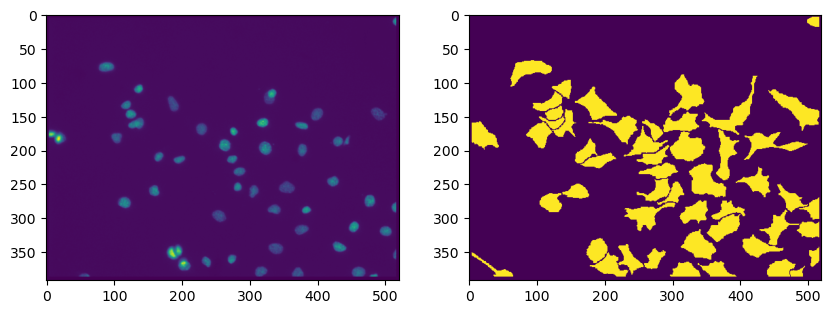

In [60]:
train_images_batch, train_labels_batch = next(iter(train_dataloader))

fig, axes = plt.subplots(ncols=2, figsize = (10,6))

image_nr = 1
axes[0].imshow(train_images_batch[image_nr,1])
axes[1].imshow(train_labels_batch[image_nr]);

### Define model

In [87]:
kernel_size = 3
nbase = [2, 32, 64, 128, 256]  # number of channels per layer
nout = 2  # number of outputs

model = Unet(nbase, nout, kernel_size)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device);

In [110]:
type(model)

models.architectures.Unet.Unet

Train model

In [ ]:
def train_model(model, dataloader, optimizer, loss_function = nn.CrossEntropyLoss()):

    for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):

        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output[:,1], labels)

        #train_losses_batch += (loss.item())

        loss.backward()

        optimizer.step()

    return model

def test_model(model, dataloader, loss_function = nn.CrossEntropyLoss()):

    with torch.no_grad():
        batch_accuracy = []
        loss = 0
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):

            output = model(images)

            loss += loss_function(output[:,1], labels).item()

            pred_labels = output[:,1].detach().numpy()
            labels = labels.detach().numpy()

            batch_accuracy.append(np.mean((labels == pred_labels).sum(axis=(1,2)) / labels[0].size))

        accuracy = np.mean(batch_accuracy)

    return accuracy, loss  
        

In [116]:
nepochs = 2

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_function = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
for epoch in tqdm(range(nepochs), desc='Epoch'):

    train_losses_batch = []

    for batch_idx, (train_images, train_labels) in tqdm(enumerate(train_dataloader), desc='batch'):

        optimizer.zero_grad()

        output = model(train_images)

        loss = loss_function(output[:,1], train_labels)

        train_losses_batch.append(loss.item())

        loss.backward()

        optimizer.step()

    train_losses.append(np.mean(train_losses_batch))

    """val_losses_batch = []
    for batch_idx, (val_images, val_labels) in enumerate(val_dataloader):

        output = model(val_images)
        
        loss = loss_function(output[:,1], train_labels)

        val_losses_batch.append(loss.item())

    #val_losses.append(np.mean(val_losses_batch))"""


batch: 8it [01:53, 14.18s/it]00:00<?, ?it/s]
batch: 8it [01:52, 14.04s/it]01:53<01:53, 113.41s/it]
Epoch: 100%|██████████| 2/2 [03:45<00:00, 112.86s/it]


In [ ]:
test_images, test_labels = next(iter(test_dataloader))

output = model(test_images)

pred_labels = output[:,1].detach().numpy() > 0.1

test_accuracy = (test_labels.detach().numpy() == pred_labels).sum(axis=(1,2)) / test_labels.detach().numpy()[0].size
test_accuracy

In [101]:
(test_labels.detach().numpy() == pred_labels).sum(axis=(1,2))

array([138585,  69341,  76551,  42816, 157626, 150718,  76693])

In [104]:
test_accuracy

array([0.81861264, 0.66748921, 0.39198391, 0.17369505, 0.71885302,
       0.77605965, 0.39065443, 0.50852139, 0.76875491, 0.69413265,
       0.36110184, 0.75384125, 0.71528159, 0.16164148, 0.34357339])

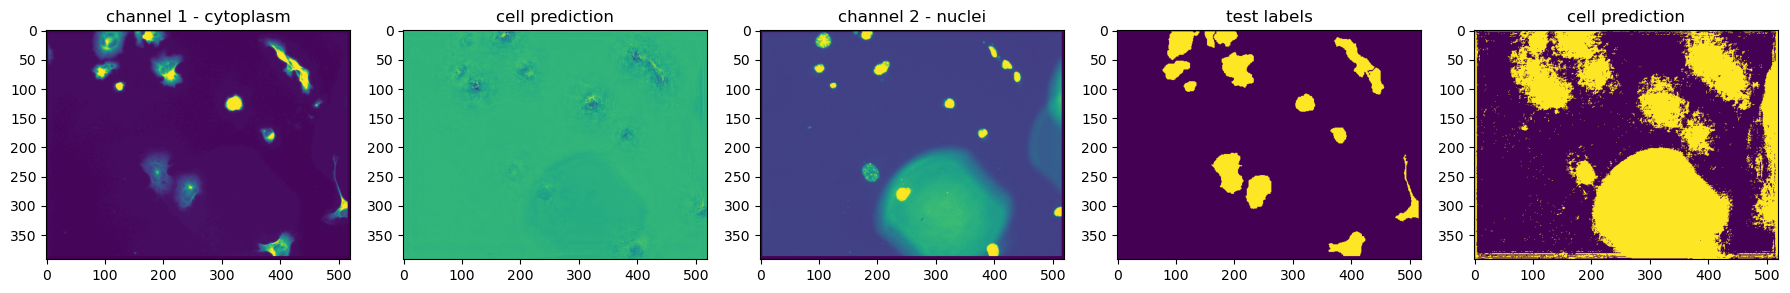

In [106]:
image_nr = 1
plt.figure(figsize=(18, 8))
plt.subplot(1, 5, 1)
plt.imshow(test_images[image_nr,0], vmin=0, vmax=1)
plt.title('channel 1 - cytoplasm')

plt.subplot(1, 5, 2)
plt.imshow(output.detach().numpy()[image_nr,0])
plt.title('cell prediction')
plt.tight_layout()
#plt.colorbar()

plt.subplot(1, 5, 3)
plt.imshow(test_images[image_nr,1], vmin=0, vmax=1)
plt.title('channel 2 - nuclei')

plt.subplot(1, 5, 4)
plt.imshow(test_labels[image_nr])
plt.title('test labels')

plt.subplot(1, 5, 5)
plt.imshow(output[image_nr,1].detach().numpy() > 0.1)
plt.title('cell prediction')
plt.tight_layout()
#plt.colorbar()
plt.show()

In [75]:
pred_labels = output[:,1].detach().numpy() > 0.1

image_nr = 0
test_labels_img = test_labels[image_nr].detach().numpy()
pred_labels_img = pred_labels[image_nr]

accuracy = (test_labels_img == pred_labels_img).sum() / test_labels_img.size

In [79]:
test_labels.detach().numpy()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [80]:
pred_labels

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [86]:
accuracy = (test_labels.detach().numpy() == pred_labels).sum() / test_labels.detach().numpy().size
accuracy

np.float64(0.9039547824624355)